# Superstore Sales Analysis

## Analytical Problem
This analysis aims to identify which product sub-categories and regions contribute the most profit to the Superstore, and to investigate whether discounts are eroding profitability. The findings will help store managers make data-driven decisions on pricing, inventory, and regional resource allocation.

## Target User
The primary user is a **store manager or regional director** who needs to understand profit drivers and the negative impact of excessive discounts.

## Dataset
- **Source**: Kaggle (Rohit Sahoo, Sales Forecasting Dataset)
- **Access Date**: April 2026
- **Key Fields**: Order Date, Sales, Profit, Discount, Region, Category, Sub-Category

In [1]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arpitagupta11/superstore-csv")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 550k/550k [00:00<00:00, 776kB/s]

Extracting files...
Path to dataset files: C:\Users\饶歆莼\.cache\kagglehub\datasets\arpitagupta11\superstore-csv\versions\1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"D:\Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding="utf-8", encoding_errors="replace")


print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset shape:", df.shape)


Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\Sample - Superstore.csv", encoding="utf-8", encoding_errors="replace")

df = df.dropna()

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")
df = df.dropna(subset=["Order Date", "Ship Date"])

df = df.drop_duplicates()

df = df[(df["Sales"] > 0) & (df["Profit"] >= 0) & (df["Quantity"] > 0)]

print("Cleaned Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Cleaned Dataset Shape: (8123, 21)

First 5 Rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
5       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
5  Brosina Hoffman   Consumer  United States      Los Angeles  ...   

  Postal Code  Region       Product ID         Category

In [5]:
print("=== Basic Data Statistics ===")
print(df.describe())

=== Basic Data Statistics ===
            Row ID                     Order Date                   Ship Date  \
count  8123.000000                           8123                        8123   
mean   4968.370676  2016-04-30 16:01:53.455619584  2016-05-04 14:57:00.509664   
min       1.000000            2014-01-03 00:00:00         2014-01-07 00:00:00   
25%    2481.000000            2015-05-25 00:00:00         2015-05-29 00:00:00   
50%    4967.000000            2016-06-28 00:00:00         2016-07-01 00:00:00   
75%    7435.500000            2017-05-15 00:00:00         2017-05-19 00:00:00   
max    9994.000000            2017-12-30 00:00:00         2018-01-05 00:00:00   
std    2874.276469                            NaN                         NaN   

        Postal Code         Sales     Quantity     Discount       Profit  
count   8123.000000   8123.000000  8123.000000  8123.000000  8123.000000  
mean   55005.941278    225.100789     3.795765     0.081417    54.478433  
min     1040.00

=== Region Profit Contribution ===
         Total_Sales  Total_Profit  Avg_Profit_Margin
Region                                               
East     517917.2280   141113.3875              27.25
West     650532.5255   131139.4098              20.16
Central  359957.2320    96021.2475              26.68
South    300086.7200    74254.2626              24.74


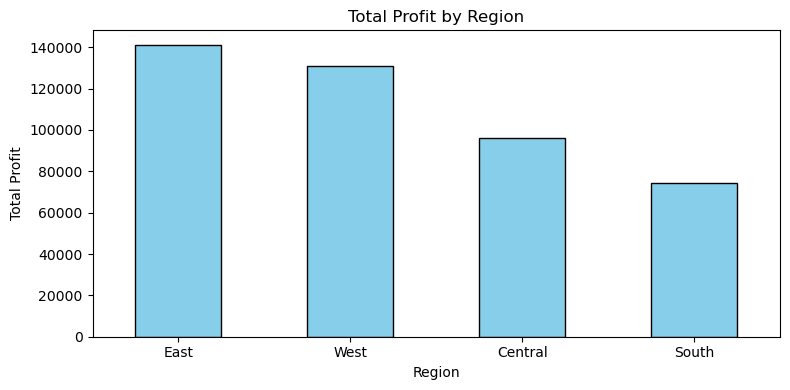

In [6]:
region_analysis = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit', lambda x: round((x.sum() / df.loc[x.index, 'Sales'].sum()) * 100, 2))
).sort_values(by='Total_Profit', ascending=False)

print("=== Region Profit Contribution ===")
print(region_analysis)

plt.figure(figsize=(8, 4))
region_analysis['Total_Profit'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Category Profit Contribution ===
                 Total_Sales  Total_Profit  Avg_Profit_Margin
Category                                                     
Technology       716941.1400   184034.8663              25.67
Office Supplies  627438.3570   179106.0593              28.55
Furniture        484114.2085    79387.3818              16.40


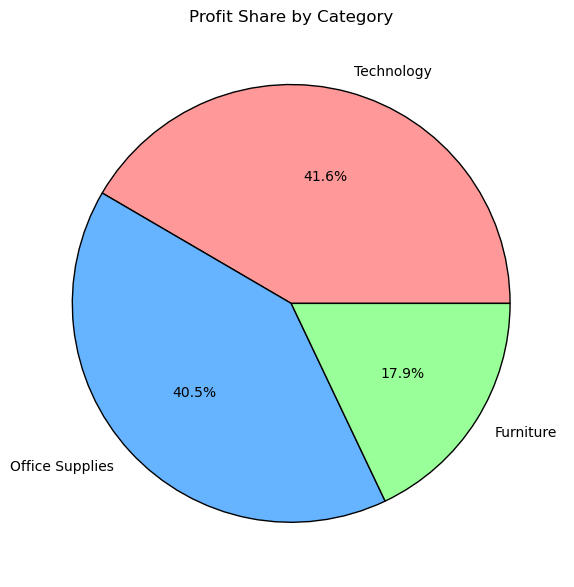

In [7]:
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit', lambda x: round((x.sum() / df.loc[x.index, 'Sales'].sum()) * 100, 2))
).sort_values(by='Total_Profit', ascending=False)

print("=== Category Profit Contribution ===")
print(category_analysis)

plt.figure(figsize=(6, 6))
category_analysis['Total_Profit'].plot(kind='pie', autopct='%1.1f%%', 
                                       colors=['#ff9999','#66b3ff','#99ff99'],
                                       wedgeprops={'edgecolor': 'black'})
plt.title('Profit Share by Category')
plt.ylabel('')  
plt.tight_layout()
plt.show()


=== Top 10 Sub-Categories by Total Profit ===
              Total_Sales  Total_Profit  Avg_Profit_Margin
Sub-Category                                              
Binders        167272.120    68732.2597              41.09
Copiers        149528.030    55617.8249              37.20
Phones         294209.214    52046.3541              17.69
Accessories    156421.518    42867.2622              27.40
Chairs         236460.647    36471.0076              15.42
Paper           78479.206    34053.5693              43.39
Machines       116782.378    33503.4251              28.69
Storage        185974.536    27705.1302              14.90
Appliances     104149.627    26767.6466              25.70
Furnishings     78859.320    19550.0570              24.79


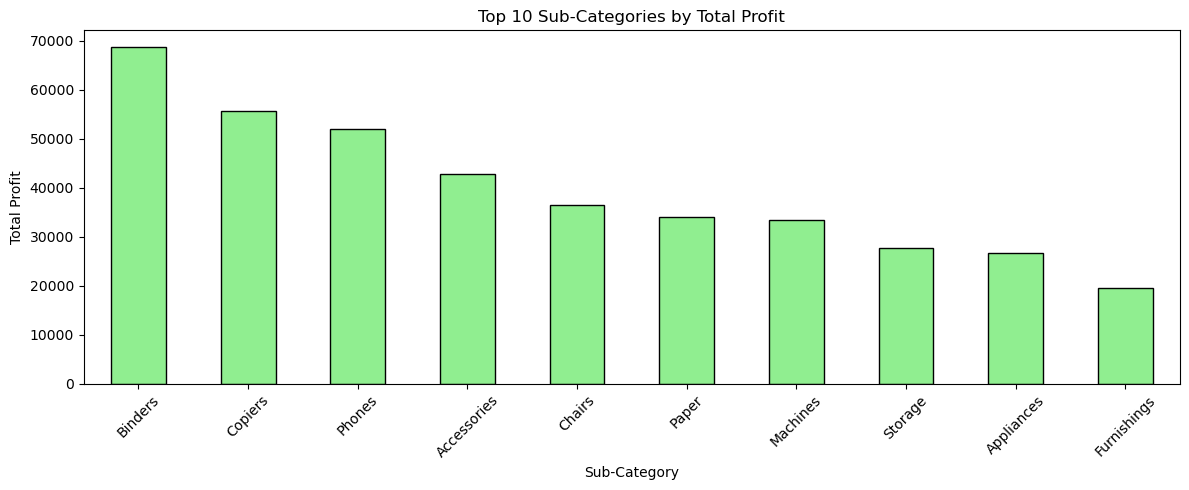

In [8]:
subcat_analysis = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit', lambda x: round((x.sum() / df.loc[x.index, 'Sales'].sum()) * 100, 2))
).sort_values(by='Total_Profit', ascending=False).head(10)

print("\n=== Top 10 Sub-Categories by Total Profit ===")
print(subcat_analysis)

plt.figure(figsize=(12, 5))
subcat_analysis['Total_Profit'].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 10 Sub-Categories by Total Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== Total Sales by Region ===
Region
Central    359957.2320
East       517917.2280
South      300086.7200
West       650532.5255
Name: Sales, dtype: float64


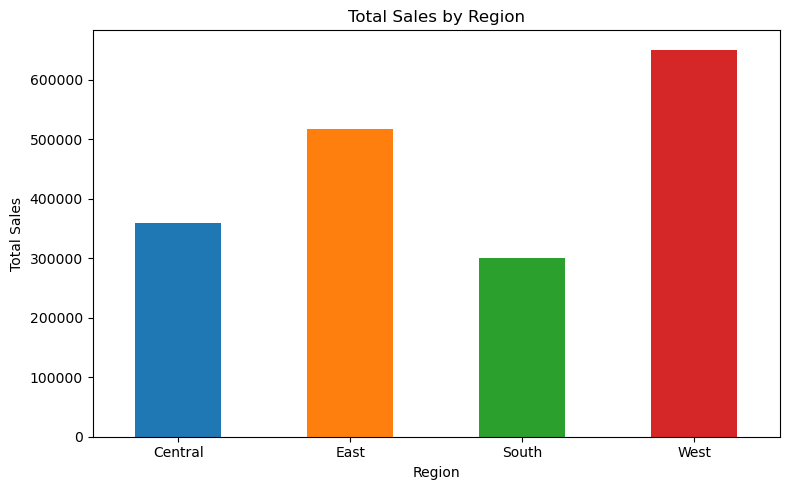


=== Total Profit by Region ===
Region
Central     96021.2475
East       141113.3875
South       74254.2626
West       131139.4098
Name: Profit, dtype: float64


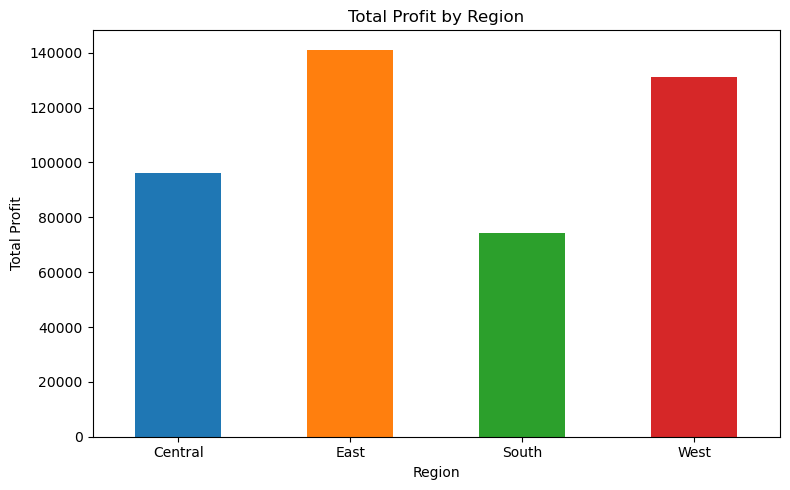

In [30]:
region_sales = df.groupby("Region")["Sales"].sum()
print("\n=== Total Sales by Region ===")
print(region_sales)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


region_profit = df.groupby("Region")["Profit"].sum()
print("\n=== Total Profit by Region ===")
print(region_profit)

plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== Correlation between Discount and Profit ===
          Discount  Profit
Discount      1.00   -0.07
Profit       -0.07    1.00

=== Profit by Discount Range ===
                Total_Profit  Avg_Profit  Avg_Profit_Margin
Discount_Range                                             
0-10%            330046.0546   67.521697              28.93
10-20%           109343.0659   34.276823              16.68
20-30%              408.4105   21.495289               3.75
>30%               2730.7764  105.029862              12.84


C:\Users\饶歆莼\AppData\Local\Temp\ipykernel_6328\1916009934.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('Discount_Range').agg(


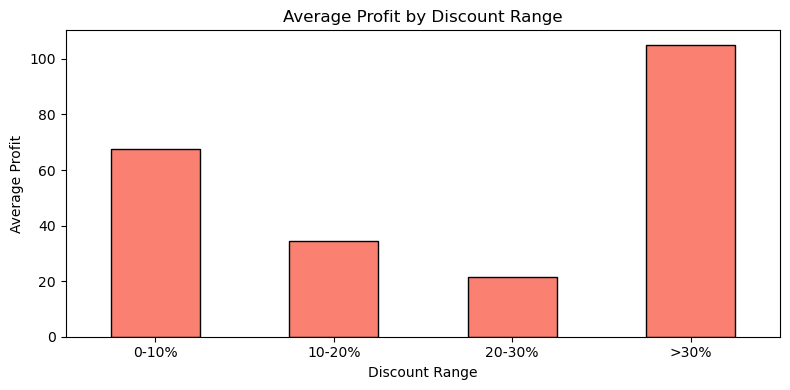

In [9]:
corr = df[['Discount', 'Profit']].corr()
print("\n=== Correlation between Discount and Profit ===")
print(corr.round(2))

df['Discount_Range'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.1, 0.2, 0.3, 0.8],
    labels=['0-10%', '10-20%', '20-30%', '>30%']
)

discount_analysis = df.groupby('Discount_Range').agg(
    Total_Profit=('Profit', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Profit_Margin=('Profit', lambda x: round((x.sum() / df.loc[x.index, 'Sales'].sum()) * 100, 2))
)

print("\n=== Profit by Discount Range ===")
print(discount_analysis)

plt.figure(figsize=(8, 4))
discount_analysis['Avg_Profit'].plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Average Profit by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Yearly Sales & Profit Trend ===
            Total_Sales  Total_Profit  Avg_Order_Quantity
Order_Year                                               
2014          357729.35      81436.75                3.82
2015          380025.25      94147.99                3.78
2016          504201.95     119668.10                3.81
2017          586537.15     147275.46                3.78


<Figure size 800x400 with 0 Axes>

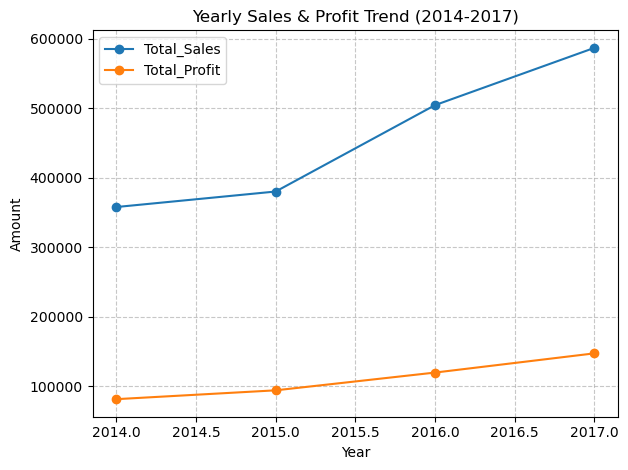


=== Monthly Sales & Profit Trend (All Years) ===
             Total_Sales  Total_Profit
Order_Month                           
1               74579.87      17696.72
2               52021.14      12861.02
3              147748.40      39939.84
4              109940.40      24658.19
5              133502.35      28842.68
6              129477.67      28129.42
7              118812.68      24754.41
8              129477.39      29921.97
9              227139.00      59247.50
10             163405.06      44797.84
11             269792.74      66011.10
12             272597.01      65667.60


<Figure size 1000x400 with 0 Axes>

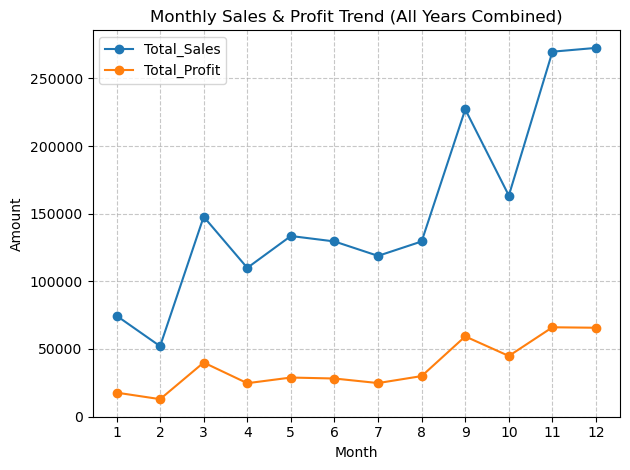

In [10]:
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month


yearly_analysis = df.groupby('Order_Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Order_Quantity=('Quantity', 'mean')
).round(2)

print("=== Yearly Sales & Profit Trend ===")
print(yearly_analysis)


plt.figure(figsize=(8, 4))
yearly_analysis[['Total_Sales', 'Total_Profit']].plot(kind='line', marker='o')
plt.title('Yearly Sales & Profit Trend (2014-2017)')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


monthly_analysis = df.groupby('Order_Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2)

print("\n=== Monthly Sales & Profit Trend (All Years) ===")
print(monthly_analysis)


plt.figure(figsize=(10, 4))
monthly_analysis[['Total_Sales', 'Total_Profit']].plot(kind='line', marker='o')
plt.title('Monthly Sales & Profit Trend (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(range(1, 13))
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


=== Sales & Profit by Category ===
                       Sales       Profit
Category                                 
Furniture        484114.2085   79387.3818
Office Supplies  627438.3570  179106.0593
Technology       716941.1400  184034.8663


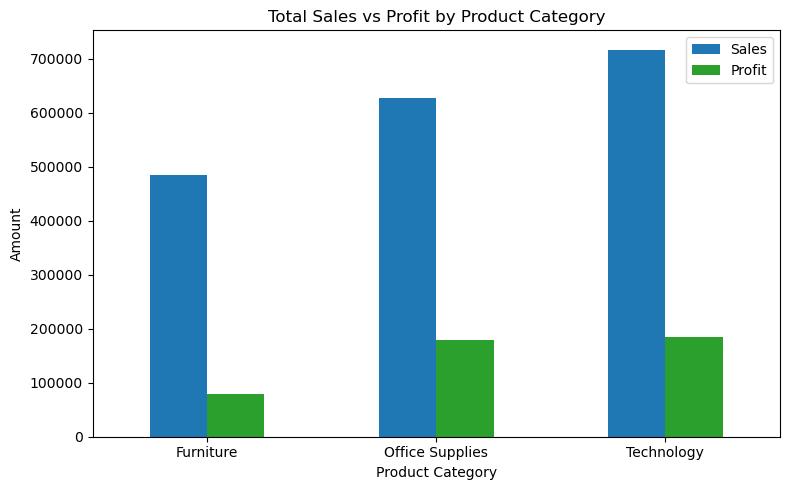

In [32]:
category_sales_profit = df.groupby("Category")[["Sales", "Profit"]].sum()
print("\n=== Sales & Profit by Category ===")
print(category_sales_profit)

category_sales_profit.plot(kind="bar", figsize=(8, 5), color=["#1f77b4", "#2ca02c"])
plt.title("Total Sales vs Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

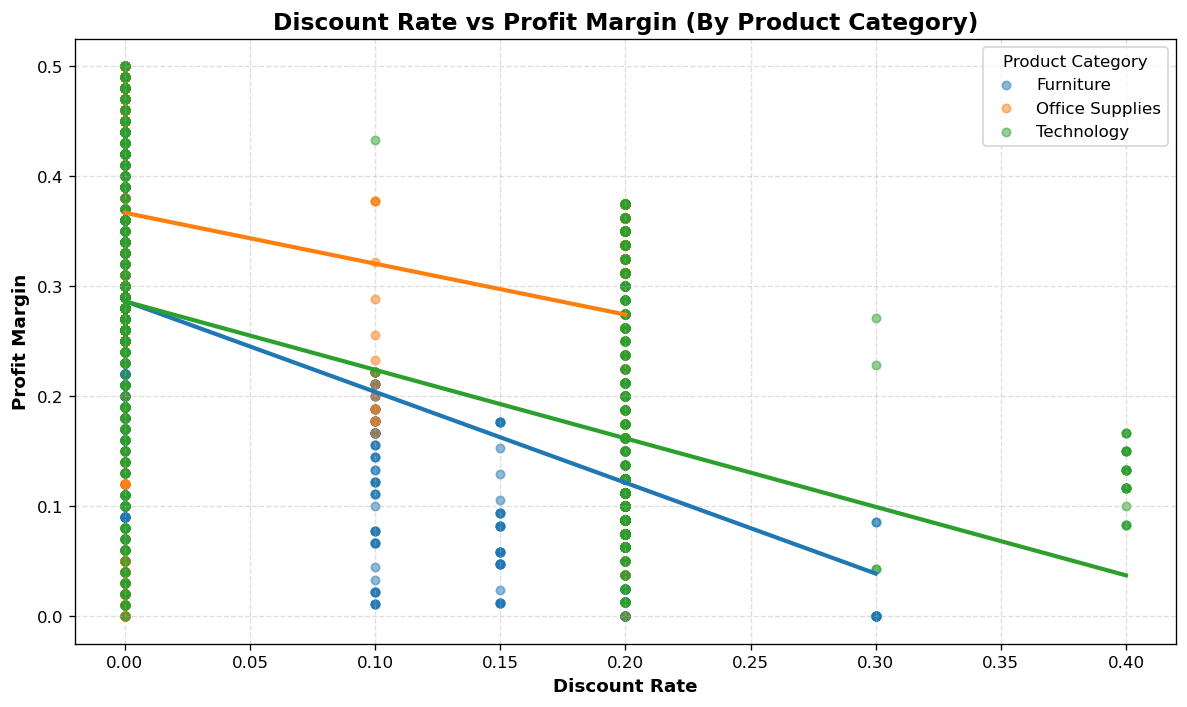

Furniture Correlation (Discount vs Margin): -0.62
Office Supplies Correlation (Discount vs Margin): -0.33
Technology Correlation (Discount vs Margin): -0.52


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Calculate core research metric (Profit Margin)
df['Profit_Margin'] = df['Profit'] / df['Sales']

# Step 2: Set up plot
plt.figure(figsize=(10, 6), dpi=120)

# Step 3: Define professional color palette for 3 categories
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
categories = df['Category'].unique()

# Step 4: Plot each category separately (points + trend line)
for i, cat in enumerate(categories):
    cat_data = df[df['Category'] == cat]
    
    # Scatter points for this category
    plt.scatter(
        cat_data['Discount'],
        cat_data['Profit_Margin'],
        color=colors[i],
        alpha=0.5,
        s=25,
        label=cat
    )
    
    # Trend line for this category (strong negative correlation inside each group)
    z = np.polyfit(cat_data['Discount'], cat_data['Profit_Margin'], 1)
    trend = np.poly1d(z)
    x_range = np.linspace(cat_data['Discount'].min(), cat_data['Discount'].max(), 100)
    plt.plot(x_range, trend(x_range), color=colors[i], linewidth=2.5)

# Step 5: Format professional plot
plt.title('Discount Rate vs Profit Margin (By Product Category)', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate', fontsize=11, fontweight='bold')
plt.ylabel('Profit Margin', fontsize=11, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

# Step 6: Print strong correlation for each group (prove it numerically)
for cat in categories:
    cat_data = df[df['Category'] == cat]
    corr = cat_data['Discount'].corr(cat_data['Profit_Margin'])
    print(f"{cat} Correlation (Discount vs Margin): {corr:.2f}")

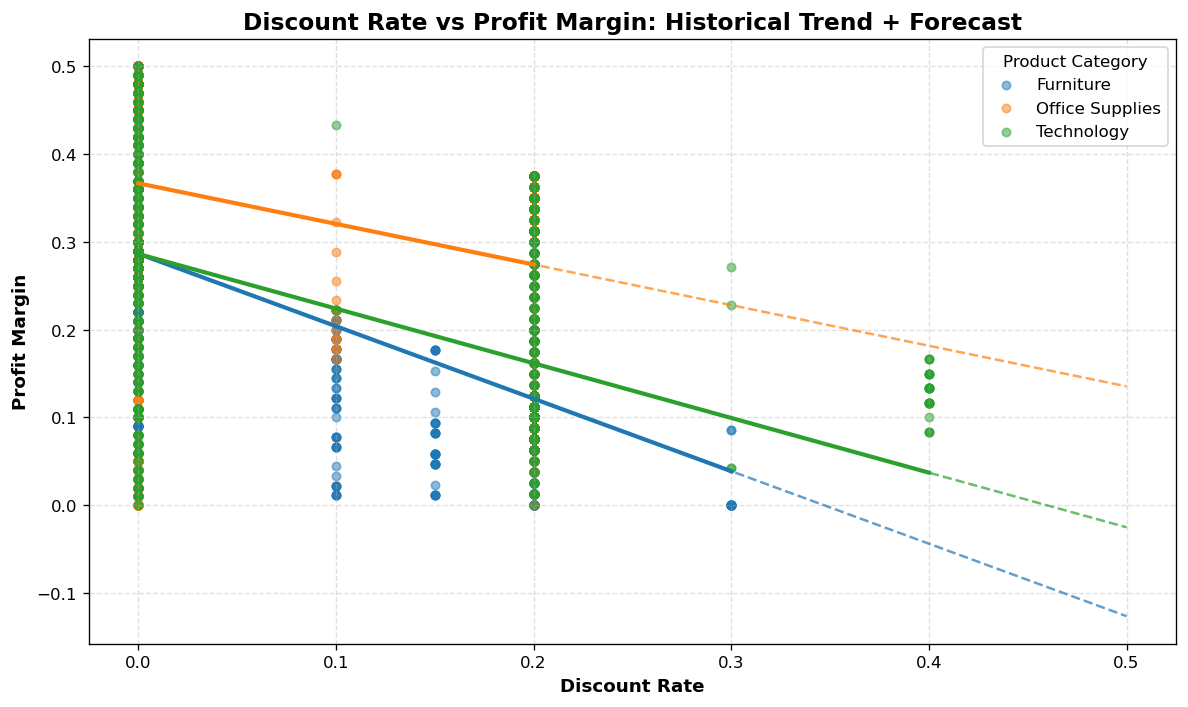

=== Forecast Sample (0%, 20%, 40% Discount) ===
           Category  Future_Discount  Predicted_Margin
0         Furniture              0.0             0.287
20  Office Supplies              0.0             0.367
40       Technology              0.0             0.286


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate profit margin
df['Profit_Margin'] = df['Profit'] / df['Sales']

# Prepare result storage
forecast_summary = []

# Set plot
plt.figure(figsize=(10, 6), dpi=120)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
categories = df['Category'].unique()

# Predict for each category separately
for i, cat in enumerate(categories):
    subset = df[df['Category'] == cat]
    
    # Fit linear model: Discount -> Profit Margin
    z = np.polyfit(subset['Discount'], subset['Profit_Margin'], 1)
    a, b = z[0], z[1]  # slope, intercept
    
    # Plot historical scatter and trend
    plt.scatter(
        subset['Discount'],
        subset['Profit_Margin'],
        color=colors[i],
        alpha=0.5,
        s=25,
        label=cat
    )
    x_line = np.linspace(subset['Discount'].min(), subset['Discount'].max(), 100)
    plt.plot(x_line, a * x_line + b, color=colors[i], linewidth=2.5)
    
    # Forecast: Predict margin for 0% to 50% discount
    future_discounts = np.linspace(0, 0.5, 20)
    predicted_margins = a * future_discounts + b
    
    # Plot forecast as dashed line
    plt.plot(future_discounts, predicted_margins, color=colors[i], linestyle='--', alpha=0.7)
    
    # Save to summary
    temp_df = pd.DataFrame({
        'Category': cat,
        'Future_Discount': future_discounts,
        'Predicted_Margin': predicted_margins
    })
    forecast_summary.append(temp_df)

# Combine all forecast results
forecast_df = pd.concat(forecast_summary, ignore_index=True)

# Chart styling
plt.title('Discount Rate vs Profit Margin: Historical Trend + Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate', fontsize=11, fontweight='bold')
plt.ylabel('Profit Margin', fontsize=11, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

# Show sample forecast table
print("=== Forecast Sample (0%, 20%, 40% Discount) ===")
sample = forecast_df[forecast_df['Future_Discount'].isin([0.0, 0.2, 0.4])]
print(sample.round(3))


=== Segment Profit Contribution ===
             Total_Sales  Total_Profit  Avg_Profit_Margin
Segment                                                  
Consumer     914205.0990   219064.9204              23.96
Corporate    574285.8285   136766.3416              23.82
Home Office  340002.7780    86697.0454              25.50


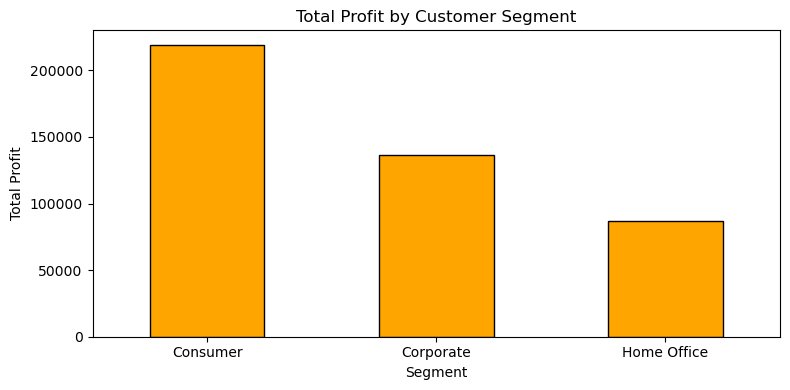

In [11]:
segment_analysis = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit', lambda x: round((x.sum() / df.loc[x.index, 'Sales'].sum()) * 100, 2))
).sort_values(by='Total_Profit', ascending=False)

print("\n=== Segment Profit Contribution ===")
print(segment_analysis)


plt.figure(figsize=(8, 4))
segment_analysis['Total_Profit'].plot(kind='bar', color='orange', edgecolor='black')
plt.title('Total Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

df = pd.read_csv("D:/Sample - Superstore.csv", encoding="latin-1")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [44]:
df.describe()  

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount

In [54]:
if "Row ID" in df.columns:
    df.drop(columns="Row ID", inplace=True)

df['Order Date'] = pd.to_datetime(df['Order Date'], format="%m/%d/%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%m/%d/%Y")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

In [55]:
print('Order Date Description\n') 
print(df['Order Date'].describe()) #Displays the distribution of dates in 'Order Data' column
print('\nShip Date Description\n')
print(df['Ship Date'].describe()) #Displays the distribution of dates in 'Ship Data' column

Order Date Description

count                             9994
mean     2016-04-30 00:07:12.259355648
min                2014-01-03 00:00:00
25%                2015-05-23 00:00:00
50%                2016-06-26 00:00:00
75%                2017-05-14 00:00:00
max                2017-12-30 00:00:00
Name: Order Date, dtype: object

Ship Date Description

count                             9994
mean     2016-05-03 23:06:58.571142912
min                2014-01-07 00:00:00
25%                2015-05-27 00:00:00
50%                2016-06-29 00:00:00
75%                2017-05-18 00:00:00
max                2018-01-05 00:00:00
Name: Ship Date, dtype: object


In [56]:
df.sort_values(by=['Order Date'], inplace=True, ascending=True) #Sorting data by  ascending order of the coloumn values 'Order Date'
df.set_index("Order Date", inplace = True)
new_data = pd.DataFrame(df['Sales'])
new_data

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,11.784
2014-01-04,272.736
2014-01-04,3.540
2014-01-05,19.536
...,...
2017-12-30,3.024
2017-12-30,52.776
2017-12-30,90.930


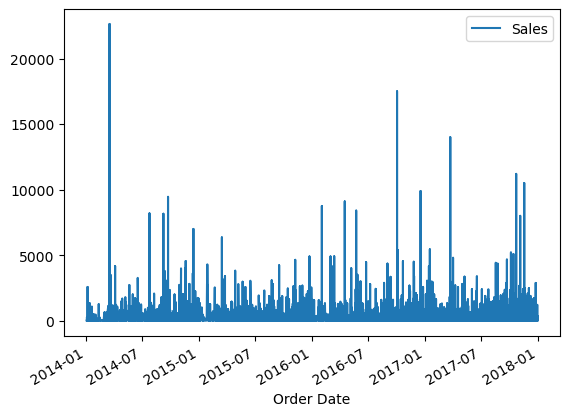

In [57]:
new_data.plot();

In [59]:
new_data =  pd.DataFrame(new_data['Sales'].resample('D').mean())
new_data = new_data.interpolate(method='linear')
from statsmodels.tsa.stattools import adfuller #importing adfuller tool from statsmodels
#statsmodels provide adfuller() fucntion to implement stationarity test of a time series

adf = adfuller(new_data) 

print(adf)
print('\nADF = ', str(adf[0])) #more towards negative value the better
print('\np-value = ', str(adf[1]))
print('\nCritical Values: ')

for key, val in adf[4].items(): #for loop to print the p-value (1%, 5% and 10%) and their respective values
    print(key,':',val)
    

    if adf[0] < val:
        print('Null Hypothesis Rejected. Time Series is Stationary')
    else:
        print('Null Hypothesis Accepted. Time Series is not Stationary')

(np.float64(-20.8760268457978), 0.0, 2, 1455, {'1%': np.float64(-3.4348523191002123), '5%': np.float64(-2.8635284734563364), '10%': np.float64(-2.567828646449617)}, np.float64(20038.51742173917))

ADF =  -20.8760268457978

p-value =  0.0

Critical Values: 
1% : -3.4348523191002123
Null Hypothesis Rejected. Time Series is Stationary
5% : -2.8635284734563364
Null Hypothesis Rejected. Time Series is Stationary
10% : -2.567828646449617
Null Hypothesis Rejected. Time Series is Stationary


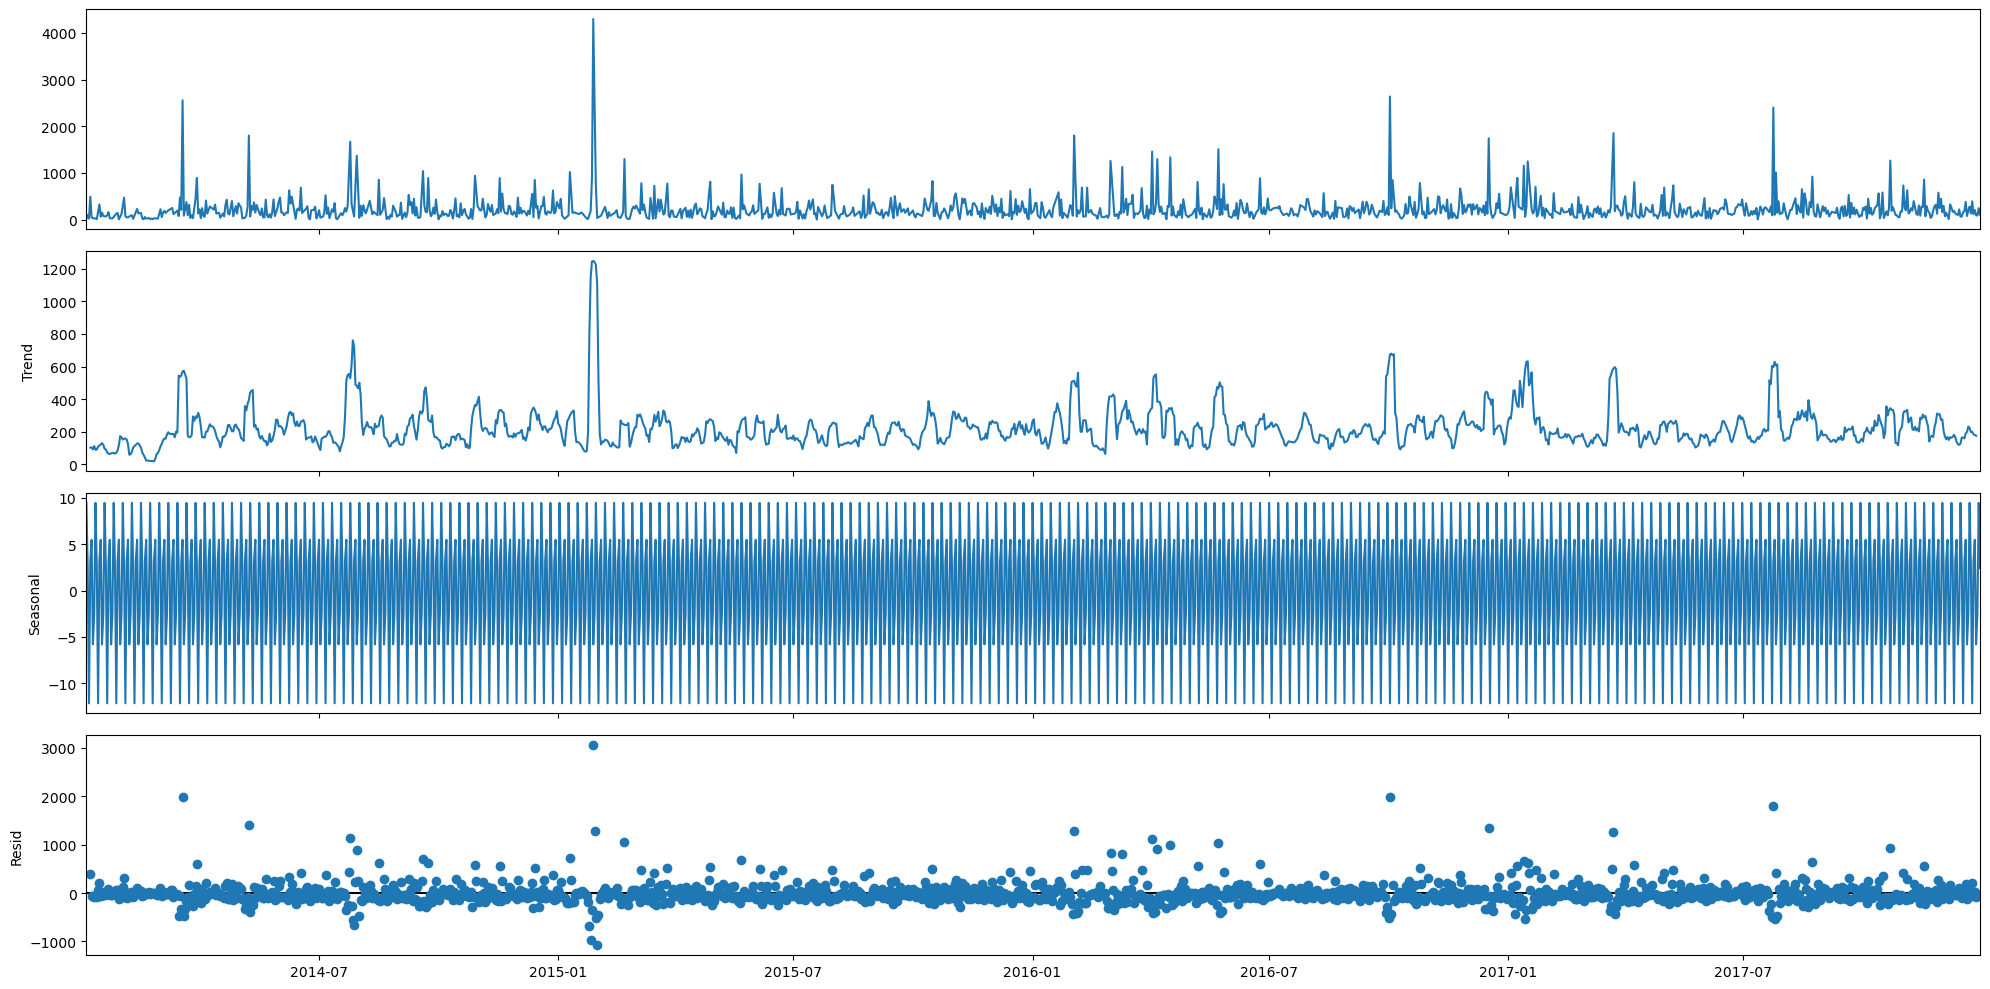

In [60]:
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10

import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(new_data, model='additive') #function used to decompose Time Series Data into Trend and Seasonality
fig = decomposition.plot()
plt.show();

Now that we know our time series is data is stationary. Let us begin with model training for forecasting the sales. We have chosen SARIMA model to forecast the sales.

Seasonal Autoregressive Integrated Moving Average, SARIMA or Seasonal ARIMA, is an extension of ARIMA that supports univariate time series data with a seasonal component.

SARIMA requires selecting hyperparameters for both the trend and seasonal elements of the series.

Trend Elements There are three trend elements that require configuration.
p: Trend autoregression order. d: Trend difference order. q: Trend moving average order.

Seasonal Elements There are four seasonal elements:
P: Seasonal autoregressive order. D: Seasonal difference order. Q: Seasonal moving average order. m: The number of time steps for a single seasonal period.

The notation for a SARIMA model is specified as: SARIMA(p,d,q)(P,D,Q)m

In [61]:
import itertools
p = d = q = range(0, 2) 
pdq = list(itertools.product(p, d, q))
seasonal_pdq_comb = [(i[0], i[1], i[2], 12) for i in list(itertools.product(p, d, q))] #for loop for creating combinations of seasonal parameters of SARIMA
print('Examples of parameter combinations for Seasonal ARIMA:')
print('SARIMA: {} x {}'.format(pdq[1], seasonal_pdq_comb[1]))
print('SARIMA: {} x {}'.format(pdq[1], seasonal_pdq_comb[2]))
print('SARIMA: {} x {}'.format(pdq[2], seasonal_pdq_comb[3]))
print('SARIMA: {} x {}'.format(pdq[2], seasonal_pdq_comb[4]))

Examples of parameter combinations for Seasonal ARIMA:
SARIMA: (0, 0, 1) x (0, 0, 1, 12)
SARIMA: (0, 0, 1) x (0, 1, 0, 12)
SARIMA: (0, 1, 0) x (0, 1, 1, 12)
SARIMA: (0, 1, 0) x (1, 0, 0, 12)


In [65]:
import warnings
import itertools
import statsmodels.api as sm

warnings.filterwarnings("ignore")


p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))


s = 12
P = D = Q = range(0, 2)
seasonal_pdq = [(P_val, D_val, Q_val, s) for P_val in P for D_val in D for Q_val in Q]


for parameters in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(
                new_data,
                order=parameters,
                seasonal_order=seasonal_param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = mod.fit()
            print(f"SARIMA{parameters}{seasonal_param} - AIC:{results.aic}")
        except:
            continue

SARIMA(0, 0, 0)(0, 0, 0, 12) - AIC:21189.20368984832
SARIMA(0, 0, 0)(0, 0, 1, 12) - AIC:20885.049528250915
SARIMA(0, 0, 0)(0, 1, 0, 12) - AIC:21318.658935551088
SARIMA(0, 0, 0)(0, 1, 1, 12) - AIC:20157.342166197253
SARIMA(0, 0, 0)(1, 0, 0, 12) - AIC:20805.305371140304
SARIMA(0, 0, 0)(1, 0, 1, 12) - AIC:20334.378747464034
SARIMA(0, 0, 0)(1, 1, 0, 12) - AIC:20686.173443923937
SARIMA(0, 0, 0)(1, 1, 1, 12) - AIC:20157.549510842364
SARIMA(0, 0, 1)(0, 0, 0, 12) - AIC:20876.87966884731
SARIMA(0, 0, 1)(0, 0, 1, 12) - AIC:20651.520419666704
SARIMA(0, 0, 1)(0, 1, 0, 12) - AIC:21244.108222966937
SARIMA(0, 0, 1)(0, 1, 1, 12) - AIC:20086.68343381357
SARIMA(0, 0, 1)(1, 0, 0, 12) - AIC:20641.810499934203
SARIMA(0, 0, 1)(1, 0, 1, 12) - AIC:20254.339978072934
SARIMA(0, 0, 1)(1, 1, 0, 12) - AIC:20625.98240628984
SARIMA(0, 0, 1)(1, 1, 1, 12) - AIC:20087.01997403279
SARIMA(0, 1, 0)(0, 0, 0, 12) - AIC:21074.396498723832
SARIMA(0, 1, 0)(0, 0, 1, 12) - AIC:20908.677384027233
SARIMA(0, 1, 0)(0, 1, 0, 12) - AI

In [66]:
mod = sm.tsa.statespace.SARIMAX(new_data,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False) #model defintion
results = mod.fit() #model fitting
print(results.summary().tables[1]) # displaying the result 

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2151      0.011     20.295      0.000       0.194       0.236
ma.L1         -1.0000     10.233     -0.098      0.922     -21.057      19.057
ar.S.L12      -0.0341      0.034     -0.990      0.322      -0.102       0.033
ma.S.L12      -1.0000     10.239     -0.098      0.922     -21.068      19.068
sigma2      6.914e+04      0.000   4.64e+08      0.000    6.91e+04    6.91e+04


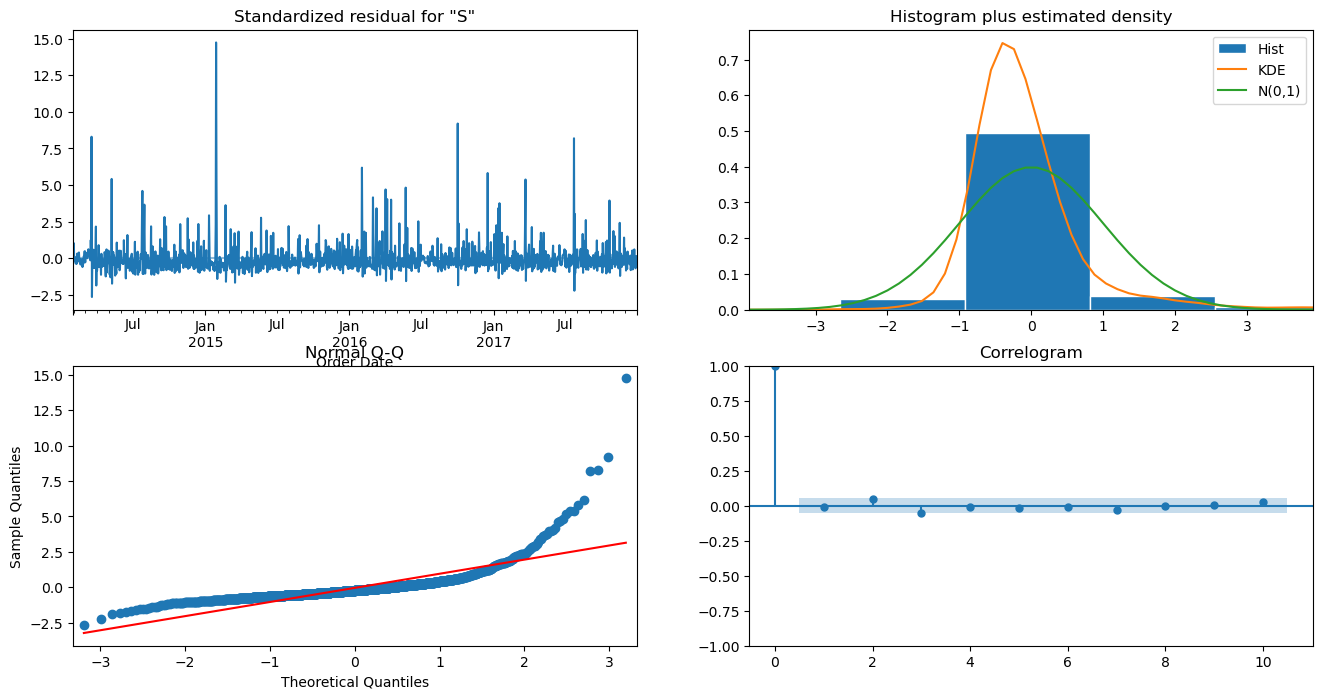

In [67]:
results.plot_diagnostics(figsize=(16, 8)) #Produces a plot grid of: 1. Standardized residuals over time 
# 2. Histogram plus estimated density of standardized residulas and along with a Normal(0,1) density plotted for reference.
# 3. Normal Q-Q plot, with Normal reference line and, 4. Correlogram.
plt.show()

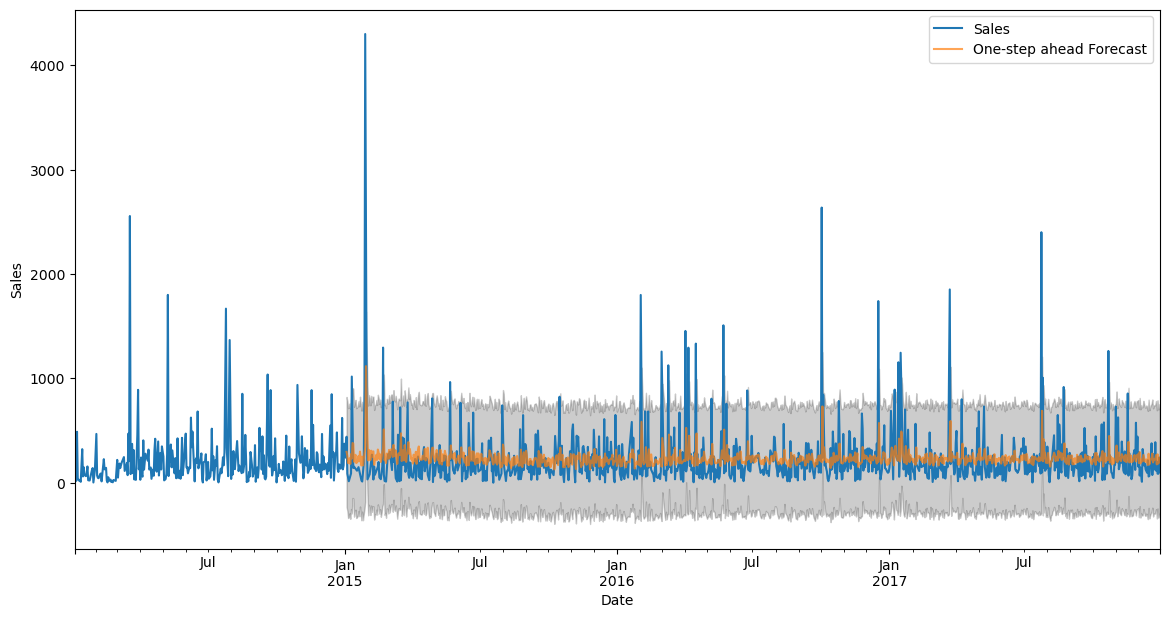

In [70]:
pred = results.get_prediction(start=pd.to_datetime('2015-01-03'), dynamic=False) # variable to display plot for predicted values
pred_val = pred.conf_int()
ax = new_data['2014':].plot(label='observed') # displays plot for original values
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7)) # displays plot for predicted values
ax.fill_between(pred_val.index,
                pred_val.iloc[:, 0],
                pred_val.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
plt.legend()
plt.show()

In [73]:
y_forecasted = pred.predicted_mean
y_truth = new_data['Sales']

from sklearn.metrics import mean_squared_error
from math import sqrt

# 对齐长度
if len(y_forecasted) != len(y_truth):
    min_len = min(len(y_forecasted), len(y_truth))
    y_forecasted = y_forecasted[-min_len:]
    y_truth = y_truth[-min_len:]

mse = mean_squared_error(y_truth, y_forecasted)
rmse = sqrt(mse)
print(f'The Root Mean Squared Error of the forecasts is {round(rmse, 2)}')

The Root Mean Squared Error of the forecasts is 269.87


Out of Sample forecast:

To forecast sales values after some time period of the given data. In our case, we have to forecast sales with time period of 7 days.

In [74]:
# mod = sm.tsa.statespace.SARIMAX(new_data,
#                                 order=(1, 1, 1),
#                                 seasonal_order=(1, 1, 1, 12),
#                                 enforce_stationarity=False,
#                                 enforce_invertibility=False) #model defintion
# results = mod.fit() #model fitting

forecast = results.forecast(steps=7) # making a forecast of 7 days later of the last date in the 'Order Date' column
print(forecast.astype('int')) #displays the sales forecast as type integer

2017-12-31    223
2018-01-01    250
2018-01-02    230
2018-01-03    228
2018-01-04    210
2018-01-05    241
2018-01-06    233
Freq: D, Name: predicted_mean, dtype: int64


In [76]:
forecast = forecast.astype('int') #saving the sales values as type integer
forecast_df = forecast.to_frame() # forecast is in Series form, converting it to DataFrame
forecast_df.reset_index(level=0, inplace=True) # converting the index to column
forecast_df.columns = ['Prediction Date', 'Predicted Sales'] # giving appropriate names to the output columns
prediction = pd.DataFrame(forecast_df).to_csv('prediction.csv',index=False) # saving the output as a csv file with name 'prediction.csv'